<a href="https://colab.research.google.com/github/kevinbinu2004-ui/Simulations-Py-/blob/main/simulation_using_runge_kutta_4th_order_rk4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Successfully loaded data from '/content/YrmeRu.csv':
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3          

/tmp/ipykernel_8278/31662538.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


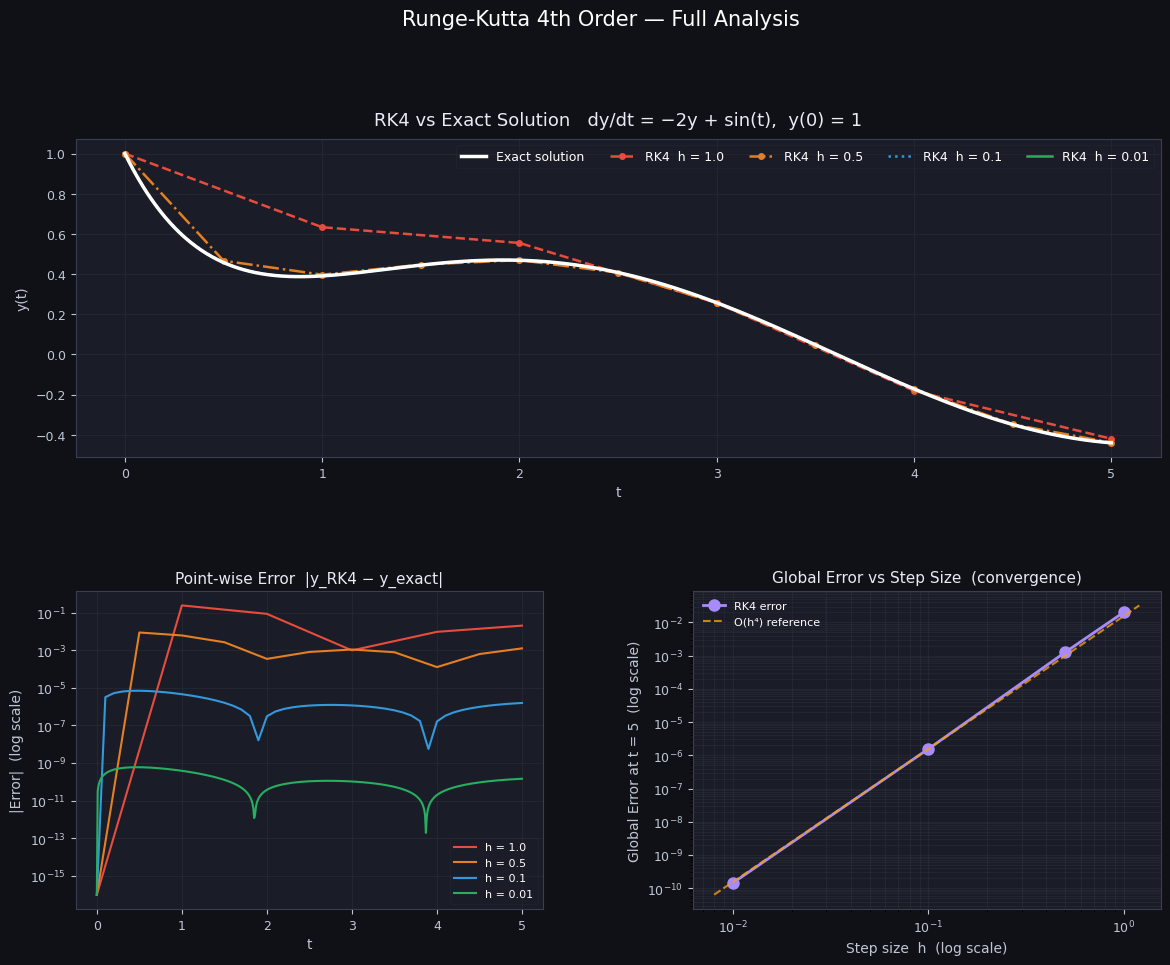

In [ ]:
# ============================================================
#  Runge-Kutta 4th Order (RK4) ODE Solver
#  ODE:   dy/dt = -2y + sin(t),   y(0) = 1
#  Exact: y(t) = (6/5)e^(-2t) + (2/5)sin(t) - (1/5)cos(t)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd # Added import for pandas

# --- Data from uploaded file ---
file_path = '/content/YrmeRu.csv'
try:
    df_uploaded_data = pd.read_csv(file_path)
    print(f"Successfully loaded data from '{file_path}':")
    print(df_uploaded_data.head())
    print(f"Shape of loaded data: {df_uploaded_data.shape}")
    # You can now use 'df_uploaded_data' in the code below.
    # Please let me know how you'd like to integrate this data into the RK4 solver or plotting.
    print("\n--- End of CSV data preview ---\n")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while reading the file '{file_path}': {e}")
# -------------------------------


# ── 1. Define the ODE and exact solution ────────────────────
def f(t, y):
    """dy/dt = -2y + sin(t)"""
    return -2 * y + np.sin(t)


def exact(t):
    """Exact analytical solution (verified with SymPy)"""
    return (6/5)*np.exp(-2*t) + (2/5)*np.sin(t) - (1/5)*np.cos(t)


# ── 2. RK4 Algorithm ────────────────────────────────────────
def rk4(f, t0, y0, t_end, h):
    """
    Classic 4th-order Runge-Kutta method.

    Parameters:
        f     : dy/dt = f(t, y)
        t0    : initial time
        y0    : initial condition y(t0)
        t_end : end time
        h     : step size

    Returns:
        t_values, y_values as numpy arrays
    """
    t_values = [t0]
    y_values = [y0]
    t = t0
    y = y0

    while t < t_end - 1e-12:
        k1 = h * f(t,         y)
        k2 = h * f(t + h/2,   y + k1/2)
        k3 = h * f(t + h/2,   y + k2/2)
        k4 = h * f(t + h,     y + k3)

        y = y + (k1 + 2*k2 + 2*k3 + k4) / 6
        t = t + h

        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)


# ── 3. Simulation parameters ────────────────────────────────
t0         = 0.0
t_end      = 5.0
y0         = 1.0
step_sizes = [1.0, 0.5, 0.1, 0.01]
colors     = ["#E74C3C", "#E67E22", "#3498DB", "#27AE60"]
styles     = ["--", "-.", ":", "-"]

# ── 4. Run RK4 for each step size ───────────────────────────
results = {}
for h in step_sizes:
    t_arr, y_arr = rk4(f, t0, y0, t_end, h)
    results[h] = (t_arr, y_arr)

# Fine grid for exact solution
t_ref = np.linspace(t0, t_end, 2000)
y_ref = exact(t_ref)

# ── 5. Print error table ─────────────────────────────────────
print(f"\n{'Step h':>8}  {'Steps':>6}  {'y(5) RK4':>14}  {'y(5) Exact':>14}  {'Global Error':>14}  {'Order':>7}")
print("-" * 78)

prev_err = None
prev_h   = None
for h in step_sizes:
    t_arr, y_arr = results[h]
    err = abs(y_arr[-1] - exact(t_arr[-1]))
    if prev_err and err > 0:
        order = f"{np.log(prev_err/err) / np.log(prev_h/h):.2f}"
    else:
        order = "  —"
    print(f"{h:>8.2f}  {len(t_arr)-1:>6d}  {y_arr[-1]:>14.8f}  {exact(t_arr[-1]):>14.8f}  {err:>14.2e}  {order:>7}")
    prev_err, prev_h = err, h

# ── 6. Plot ──────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), facecolor="#0F1117")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, :])   # top: solution curves
ax2 = fig.add_subplot(gs[1, 0])   # bottom-left: error over time
ax3 = fig.add_subplot(gs[1, 1])   # bottom-right: convergence

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor("#1A1D27")
    ax.tick_params(colors="#C0C7D4", labelsize=9)
    ax.spines[:].set_color("#3A3F50")
    ax.yaxis.label.set_color("#C0C7D4")
    ax.xaxis.label.set_color("#C0C7D4")
    ax.title.set_color("#E8EBF4")

# Panel 1 — Solution curves
ax1.plot(t_ref, y_ref, color="white", lw=2.5, label="Exact solution", zorder=5)
for h, color, ls in zip(step_sizes, colors, styles):
    t_arr, y_arr = results[h]
    ax1.plot(t_arr, y_arr, color=color, lw=1.8, ls=ls,
             label=f"RK4  h = {h}", zorder=4,
             marker="o", markersize=4 if h >= 0.5 else 0, markevery=1)

ax1.set_title("RK4 vs Exact Solution   dy/dt = −2y + sin(t),  y(0) = 1", fontsize=13, pad=10)
ax1.set_xlabel("t")
ax1.set_ylabel("y(t)")
ax1.legend(framealpha=0.15, labelcolor="white", fontsize=9,
           facecolor="#1A1D27", edgecolor="#3A3F50", ncol=5)
ax1.grid(alpha=0.15, color="#5A5F70")

# Panel 2 — Point-wise error over time
for h, color in zip(step_sizes, colors):
    t_arr, y_arr = results[h]
    err_arr = np.abs(y_arr - exact(t_arr))
    ax2.semilogy(t_arr, err_arr + 1e-16, color=color, lw=1.5, label=f"h = {h}")

ax2.set_title("Point-wise Error  |y_RK4 − y_exact|", fontsize=11)
ax2.set_xlabel("t")
ax2.set_ylabel("|Error|  (log scale)")
ax2.legend(framealpha=0.15, labelcolor="white", fontsize=8,
           facecolor="#1A1D27", edgecolor="#3A3F50")
ax2.grid(alpha=0.15, color="#5A5F70", which="both")

# Panel 3 — Convergence plot (log-log)
h_vals   = np.array(step_sizes)
g_errors = np.array([abs(results[h][1][-1] - exact(results[h][0][-1])) for h in h_vals])

ax3.loglog(h_vals, g_errors, "o-", color="#A78BFA", lw=2, markersize=8, label="RK4 error")

h_ref  = np.array([min(h_vals)*0.8, max(h_vals)*1.2])
slope4 = g_errors[-2] / h_vals[-2]**4 * h_ref**4
ax3.loglog(h_ref, slope4, "--", color="#F59E0B", lw=1.5, alpha=0.8, label="O(h⁴) reference")

ax3.set_title("Global Error vs Step Size  (convergence)", fontsize=11)
ax3.set_xlabel("Step size  h  (log scale)")
ax3.set_ylabel("Global Error at t = 5  (log scale)")
ax3.legend(framealpha=0.15, labelcolor="white", fontsize=8,
           facecolor="#1A1D27", edgecolor="#3A3F50")
ax3.grid(alpha=0.15, color="#5A5F70", which="both")

plt.suptitle("Runge-Kutta 4th Order — Full Analysis", fontsize=15, color="white", y=1.01)
fig.tight_layout()
plt.show()